## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001B51DF805C0> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469


In [6]:
timeline_file.shape

(3067208, 33)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [8]:
wnv_file.shape

(378, 4)

### Add mosquito predictions from trained model

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [11]:
dataset.dtypes

NUTS2_ID               object
NUTS2_NAME             object
NUTS3_ID               object
NUTS3_NAME             object
x                     float64
y                     float64
dt_placement           object
day                     int64
month                   int64
year                    int64
ndvi                  float64
ndmi                  float64
ndwi                  float64
ndbi                  float64
ndvi_mean             float64
ndmi_mean             float64
ndwi_mean             float64
ndbi_mean             float64
ndvi_std              float64
ndmi_std              float64
ndwi_std              float64
ndbi_std              float64
lst_day               float64
lst_night             float64
lst_day_jan_mean      float64
lst_day_feb_mean      float64
lst_day_mar_mean      float64
lst_day_apr_mean      float64
lst_night_jan_mean    float64
lst_night_feb_mean    float64
lst_night_mar_mean    float64
lst_night_apr_mean    float64
rainfall              float64
lst       

In [12]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [16]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [17]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [18]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

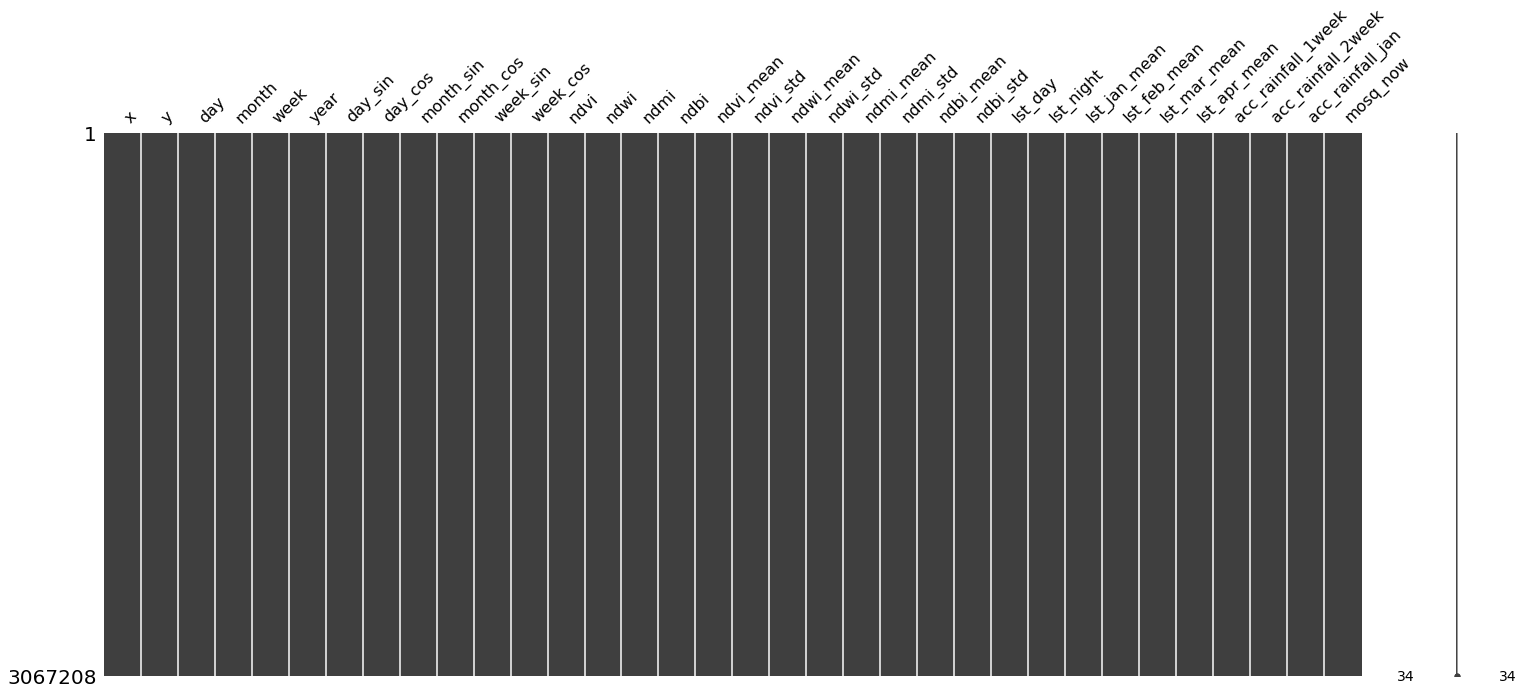

In [19]:
missingno.matrix(dataset_mamoth)

In [20]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [21]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [22]:
predictions = give_predictions(model, dataset_mamoth)

In [23]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.784110,40.821750,2010-01-01,13
1,21.784110,40.821750,2010-01-02,14
2,21.784110,40.821750,2010-01-03,17
3,21.784110,40.821750,2010-01-04,27
4,21.784110,40.821750,2010-01-05,25
...,...,...,...,...
3067203,24.069540,40.979960,2022-12-27,1
3067204,24.069540,40.979960,2022-12-28,1
3067205,24.069540,40.979960,2022-12-29,1
3067206,24.069540,40.979960,2022-12-30,1


<AxesSubplot:>

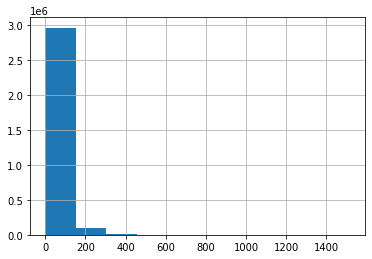

In [24]:
mosqutio_predictions.mosq_pred.hist()

In [25]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2010_2022.csv", encoding = enc, index = False)

In [26]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [27]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,3.768066,13965.000000,13965.000000,NaN,NaN,NaN,3.768066,3.768066,3.768066,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13
1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,2.864009,13965.000000,13965.000000,NaN,NaN,NaN,6.632075,6.632075,6.632075,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,14
2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13776.000000,NaN,NaN,NaN,1.146590,13789.500000,13906.500000,NaN,NaN,NaN,7.778665,7.778665,7.778665,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,17
3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13717.500000,NaN,NaN,NaN,0.413468,13789.500000,13877.250000,NaN,NaN,NaN,8.192133,8.192133,8.192133,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,27
4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13682.400000,NaN,NaN,NaN,2.318093,13789.500000,13859.700000,NaN,NaN,NaN,10.510226,10.510226,10.510226,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-27,27,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14157.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14014.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.756312,1446.142168,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1
3067204,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14043.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,13957.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3067205,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-29,29,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14154.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14012.500000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,1
3067206,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-30,30,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14110.000000,13907.000000,13899.500000,1

In [70]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [71]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [72]:
dataset_locations

,x,y
0,21.784110,40.821750
1,21.837380,40.781330
2,21.837380,40.821750
3,21.837380,40.862180
4,21.837380,40.943030
...,...,...
641,23.962800,41.060810
642,24.016170,40.939540
643,24.016170,40.979960
644,24.016170,41.020390


In [73]:
dataset_locations_per_year

,x,y,year
0,21.784110,40.821750,2010
1,21.784110,40.821750,2011
2,21.784110,40.821750,2012
3,21.784110,40.821750,2013
4,21.784110,40.821750,2014
...,...,...,...
8393,24.069540,40.979960,2018
8394,24.069540,40.979960,2019
8395,24.069540,40.979960,2020
8396,24.069540,40.979960,2021


In [74]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [75]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.05555976174710023
Max distance: 16.21314174752167


In [76]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [77]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.784110,40.821750,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
1,21.837380,40.781330,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
2,21.837380,40.821750,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
3,21.837380,40.862180,14591.608490,1149.924232,16,87.848197,1312.399181,120.888527,0.000000,12.005094
4,21.837380,40.943030,14591.608490,1149.924232,16,87.848197,1312.399181,120.888527,0.000000,12.005094
...,...,...,...,...,...,...,...,...,...,...
641,23.962800,41.060810,26135.993115,2009.977772,7,97.489887,163.027213,166.978174,0.000000,1.467206
642,24.016170,40.939540,19050.703095,1920.288480,25,115.624237,535.486154,203.427221,0.000000,2.127202
643,24.016170,40.979960,19050.703095,1920.288480,25,115.624237,535.486154,203.427221,0.000000,2.127202
644,24.016170,41.020390,29906.679762,1253.220245,2,97.250789,66.135786,176.969728,0.000000,10.412671


In [78]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [79]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [80]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [81]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.784110,40.821750,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
1,21.837380,40.781330,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
2,21.837380,40.821750,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
3,21.837380,40.862180,14591.608490,1149.924232,16,87.848197,1312.399181,120.888527,0.000000,12.005094
4,21.837380,40.943030,14591.608490,1149.924232,16,87.848197,1312.399181,120.888527,0.000000,12.005094
...,...,...,...,...,...,...,...,...,...,...
641,23.962800,41.060810,26135.993115,2009.977772,7,97.489887,163.027213,166.978174,0.000000,1.467206
642,24.016170,40.939540,19050.703095,1920.288480,25,115.624237,535.486154,203.427221,0.000000,2.127202
643,24.016170,40.979960,19050.703095,1920.288480,25,115.624237,535.486154,203.427221,0.000000,2.127202
644,24.016170,41.020390,29906.679762,1253.220245,2,97.250789,66.135786,176.969728,0.000000,10.412671


In [82]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [83]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [84]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [85]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [86]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [87]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2011
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2012
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2013
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2014
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2015
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2016
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2017
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2018
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2019
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2020
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2021
Min distance: 0.05555976174710023
Max distance: 16.21314174752167
Year: 2022
Min distance: 0.05555976174710023
Max distance: 16.21314174752167

In [88]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [89]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.784110,40.821750,2010,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
1,21.837380,40.781330,2010,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
2,21.837380,40.821750,2010,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
3,21.837380,40.862180,2010,14,99,10,99.000000,10,99,4,4,6,4,4,2,0
4,21.837380,40.943030,2010,14,99,10,99.000000,10,99,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8393,23.962800,41.060810,2022,31,96,36,96.000000,30,96,12,12,3,5,8,2,0
8394,24.016170,40.939540,2022,11,94,10,95.000000,10,95,1,1,7,1,1,2,0
8395,24.016170,40.979960,2022,11,94,10,95.000000,10,95,1,1,7,1,1,2,0
8396,24.016170,41.020390,2022,31,99,36,99.000000,30,99,12,12,3,5,8,2,0


In [90]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [91]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [92]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [93]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,3.768066,13965.000000,13965.000000,NaN,NaN,NaN,3.768066,3.768066,3.768066,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,2.864009,13965.000000,13965.000000,NaN,NaN,NaN,6.632075,6.632075,6.632075,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,14,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13776.000000,NaN,NaN,NaN,1.146590,13789.500000,13906.500000,NaN,NaN,NaN,7.778665,7.778665,7.778665,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,17,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13717.500000,NaN,NaN,NaN,0.413468,13789.500000,13877.250000,NaN,NaN,NaN,8.192133,8.192133,8.192133,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,27,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13682.400000,NaN,NaN,NaN,2.318093,13789.500000,13859.700000,NaN,NaN,NaN,10.510226,10.510226,10.510226,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,25,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,31,95,30,95.000000,30,95,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-27,27,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14157.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14014.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.756312,1446.142168,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1,19050.703095,1920.288480,25,115.624237,535.486154,203.427221,0.000000,2.127202,11,94,10,95.000000,10,95,1,1,7,1,1,2,0
3067204,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN

In [94]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [95]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [96]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [97]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [98]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [99]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.173470,40.603370,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14258.000000,14066.000000,14258.000000,NaN,NaN,NaN,14066.000000,NaN,NaN,NaN,2.111555,14313.000000,14313.000000,NaN,NaN,NaN,2.111555,2.111555,2.111555,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13,6100.105828,763.626296,2,123.620976,40.180695,169.450815,0.000000,1.415458,31,99,36,99.000000,30,83,12,12,1,6,7,2,0
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.100270,40.693770,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14317.000000,14000.000000,14317.000000,NaN,NaN,NaN,14000.000000,NaN,NaN,NaN,0.000000,14157.500000,14157.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,16,1496.712495,2482.713363,4,177.316610,178.873522,183.175945,0.000000,1.000000,31,96,30,96.000000,30,96,10,10,1,6,6,2,0
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.810850,41.012690,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14336.000000,14020.000000,14336.000000,NaN,NaN,NaN,14020.000000,NaN,NaN,NaN,0.000000,14126.000000,14126.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,11,9003.134241,3690.955644,2,161.990273,182.240771,180.858595,0.000000,1.000000,31,98,36,98.000000,30,98,12,12,3,5,8,2,0
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,21.997200,40.821750,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13943.000000,14037.000000,NaN,NaN,NaN,13943.000000,NaN,NaN,NaN,0.000000,13870.000000,13870.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13,29517.602842,978.661775,1,133.200207,3.656311,179.967324,0.000000,1.000000,31,86,20,99.000000,30,86,12,9,4,4,4,2,0
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.498860,40.249090,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14528.000000,14152.000000,14528.000000,NaN,NaN,NaN,14152.000000,NaN,NaN,NaN,0.747937,14354.000000,14354.000000,NaN,NaN,NaN,0.747937,0.747937,0.747937,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,26,16950.309844,514.120983,13,137.070105,299.513511,178.948787,0.000000,1.113113,31,87,36,96.000000,30,96,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.810850,41.012690,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14235.000000,13801.000000,14032.333333,14043.000000,13844.064516,13844.064516,13672.129032,13711.071429,13578.451613,13578.451613,0.000000,14041.000000,13810.406452,14052.982143,13781.338710,13781.338710,0.000000,0.000000,988.026307,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,1,9003.134241,3690.955644,2,161.990273,182.240771,180.858595,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,3,5,8,2,0
33232,2022-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,21.997200,40.821750,31,12,2022,0.118745,-0.144

In [100]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.401250,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13849.000000,13608.000000,13849.000000,NaN,NaN,NaN,13608.000000,NaN,NaN,NaN,0.000000,13791.500000,13791.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,11,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,14,69,10,68.000000,10,72,4,4,1,2,2,2,0
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,22.622870,40.410790,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13951.000000,13892.000000,13951.000000,NaN,NaN,NaN,13892.000000,NaN,NaN,NaN,0.000000,14005.000000,14005.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,10,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,11,74,9,74.000000,10,74,8,8,1,1,1,2,0
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.383700,40.850990,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13782.000000,13662.000000,13782.000000,NaN,NaN,NaN,13662.000000,NaN,NaN,NaN,0.000000,13853.500000,13853.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,7,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,14,69,10,69.000000,10,69,4,4,1,4,4,2,0
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.700480,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13338.000000,13536.000000,13338.000000,NaN,NaN,NaN,13536.000000,NaN,NaN,NaN,0.000000,13612.500000,13612.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,5,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,14,73,10,73.000000,10,73,4,4,1,1,1,2,0
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.235210,40.006530,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13841.000000,13805.000000,13841.000000,NaN,NaN,NaN,13805.000000,NaN,NaN,NaN,0.087795,13861.500000,13861.500000,NaN,NaN,NaN,0.087795,0.087795,0.087795,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,14,74,10,74.000000,10,74,4,4,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.383700,40.850990,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14109.000000,13729.000000,13897.200000,14043.000000,13844.064516,13844.064516,13507.612903,13617.500000,13578.451613,13578.451613,0.000000,13970.500000,13762.274194,13877.589286,13781.338710,13781.338710,-0.000000,0.000000,891.448593,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,1,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,14,71,10,71.000000,10,71,4,4,1,4,4,2,0
33232,2022-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.700480,31,12,2022,0.118745,-0.144385,-0.465034,-0.

In [101]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [102]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14136.074074,1.216681,17.781818,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14195.208661,0.020066,15.803150,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14143.906593,0.000223,11.582418,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14105.909091,0.406945,13.511364,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14283.244444,1.073789,25.200000,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,31,12,2022,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.08

<AxesSubplot:>

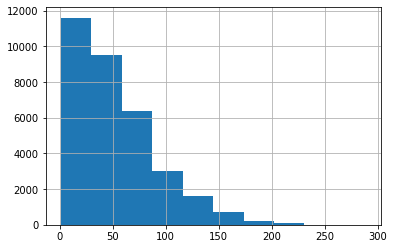

In [103]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [104]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

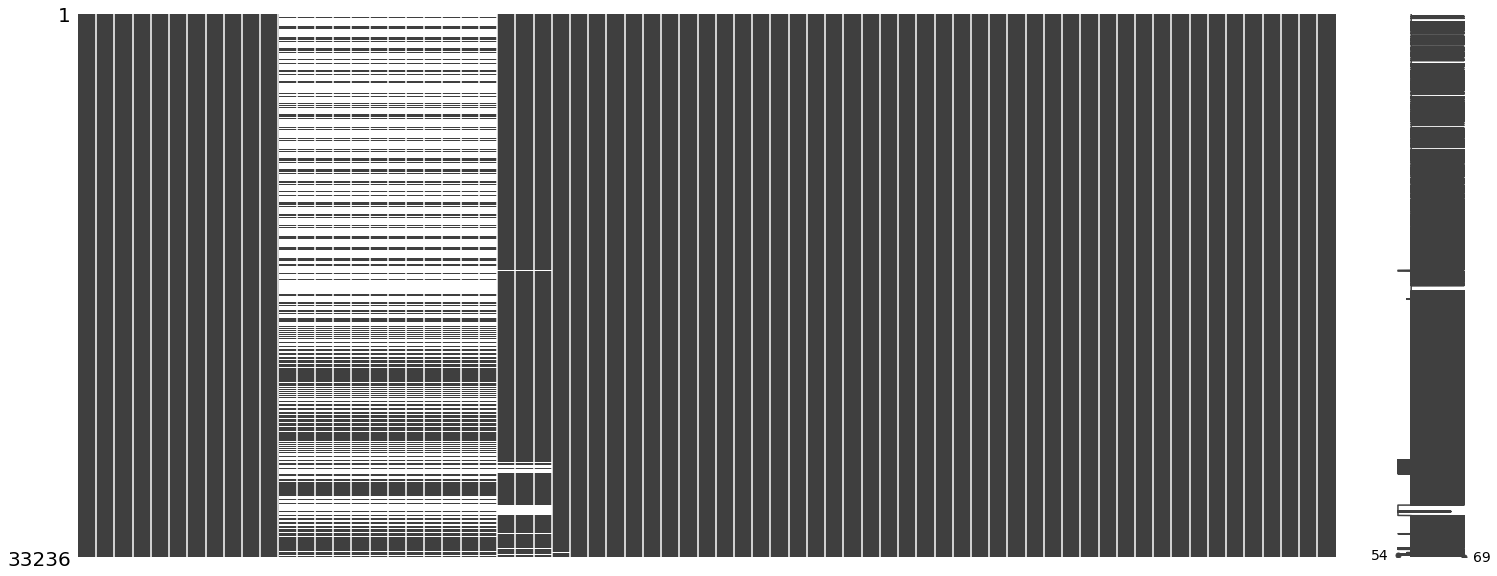

In [105]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [106]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [107]:
bio_values_df = pd.DataFrame(bio_values)

In [108]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,ημαθια,2010,1,-0.015091,12.092545,81.134845
1,ημαθια,2010,2,-4.002083,11.714000,285.842680
2,ημαθια,2010,3,0.445636,21.507455,117.454131
3,ημαθια,2010,4,4.902364,27.275455,74.304749
4,ημαθια,2010,5,9.828182,31.784182,122.568711
...,...,...,...,...,...,...
1087,χαλκιδικη,2022,8,19.273256,36.570930,270.000928
1088,χαλκιδικη,2022,9,9.603953,29.738140,179.236105
1089,χαλκιδικη,2022,10,10.735814,26.349535,15.719672
1090,χαλκιδικη,2022,11,4.033488,23.691860,18.718064


In [109]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [110]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,9.525347,1.216681,17.781818,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,10.754173,0.020066,15.803150,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,9.728132,0.000223,11.582418,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,8.968182,0.406945,13.511364,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2,-3.823409,11.261136,81.491186
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,12.514889,1.073789,25.200000,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

<AxesSubplot:>

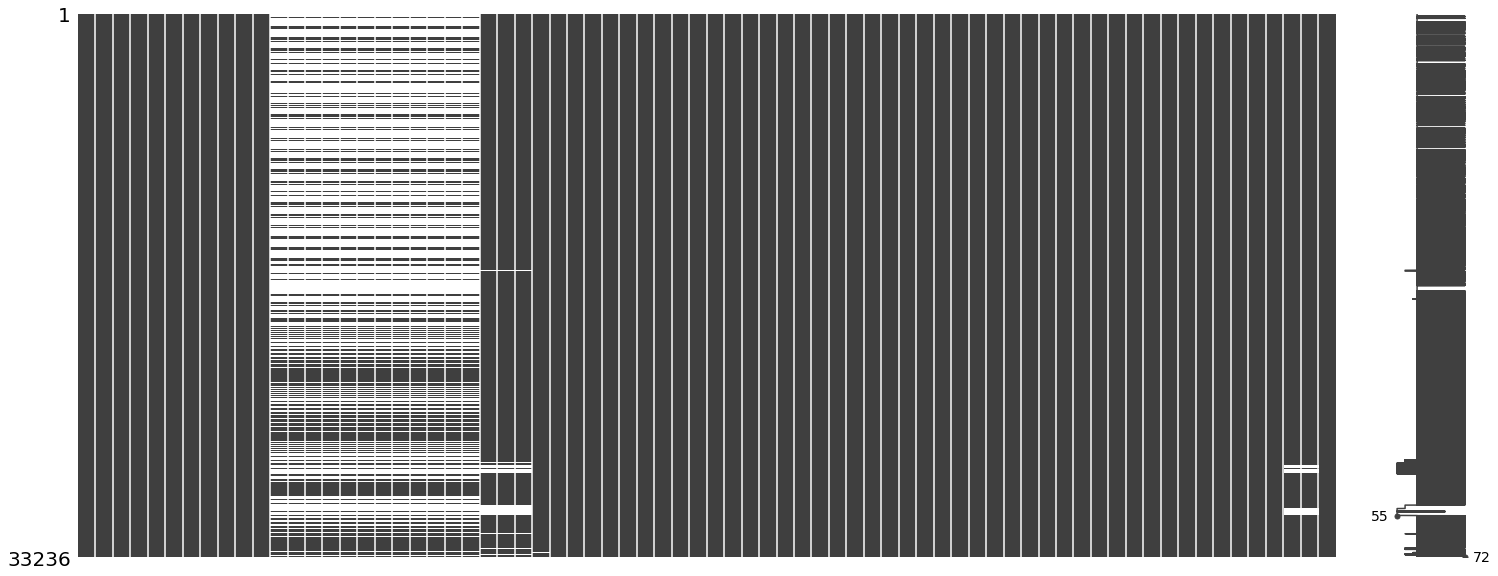

In [111]:
missingno.matrix(dataset)

In [112]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [113]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [114]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,9.525347,1.216681,17.781818,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,2010-01
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,10.754173,0.020066,15.803150,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748,2010-01
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,9.728132,0.000223,11.582418,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589,2010-01
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,8.968182,0.406945,13.511364,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2,-3.823409,11.261136,81.491186,2010-01
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,1,2010,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,12.514889,1.073789,25.200000,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2,1.550444,15.961111,81.927242,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [115]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.387455,0.676545,0.437091,0.000000,17.781818,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845
1,1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,1,2010,1,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,3.669055,3.845433,0.425984,0.000000,14.102362,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748
2,2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,1,2010,1,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,3.457253,2.602967,-0.719341,0.000000,11.582418,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589
3,3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.155455,2.848182,5.501818,0.000000,13.511364,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2,-3.823409,11.261136,81.491186
4,4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,1,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.470889,1.613111,1.881333,0.000000,23.755556,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [116]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [117]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,4.816764,1.364895,740.125984,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,3.765541,1.715277,631.285714,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,3.694941,2.628748,869.318182,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2,-3.823409,11.261136,81.491186
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,6.091283,2.642814,1130.755556,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [118]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [119]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1092 non-null   period[M]
 1   NUTS2_ID                1092 non-null   object   
 2   NUTS2_NAME              1092 non-null   object   
 3   NUTS3_ID                1092 non-null   object   
 4   NUTS3_NAME              1092 non-null   object   
 5   x                       1092 non-null   float64  
 6   y                       1092 non-null   float64  
 7   month                   1092 non-null   int64    
 8   year                    1092 non-null   int64    
 9   ndvi                    1035 non-null   float64  
 10  ndmi                    1035 non-null   float64  
 11  ndwi                    1035 non-null   float64  
 12  ndbi                    1035 non-null   float64  
 13  ndvi_mean               1036 non-null   float64  
 14  ndmi_mea

In [120]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    378 non-null    object
 1   NUTS3_NAME    378 non-null    object
 2   dt_placement  378 non-null    object
 3   cases         378 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 11.9+ KB


In [121]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [122]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0
...,...,...,...,...
373,κεντρικη μακεδονια,χαλκιδικη,2022-07,0
374,κεντρικη μακεδονια,χαλκιδικη,2022-08,12
375,κεντρικη μακεδονια,χαλκιδικη,2022-09,10
376,κεντρικη μακεδονια,χαλκιδικη,2022-10,1


In [123]:
wnv_file['cases'].value_counts()

0     240
1      39
2      22
3      17
4      10
5       8
11      5
6       5
10      5
7       5
12      4
13      3
8       2
17      2
20      2
16      1
9       1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [124]:
wnv_file.cases.sum()

863

In [125]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [126]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,4.816764,1.364895,740.125984,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,3.765541,1.715277,631.285714,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,3.694941,2.628748,869.318182,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.000000,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,31,20,30,12,9,4,4,4,2,-3.823409,11.261136,81.491186,NaN
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,6.091283,2.642814,1130.755556,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,3000.937284,94.562229,2,62.313885,93.538557,146.595411,0.000000,1.000000,19524.949575,2536.018282,32,280.276793,1415.512836,178.948787,0.000000,160.175056,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,31,36,30,12,12,1,6,7,2,1.550444,15.961111,81.927242,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [127]:
merged = fillna(merged,{'cases': 0})

In [128]:
merged['cases'].value_counts()

0.000000     954
1.000000      39
2.000000      22
3.000000      17
4.000000      10
5.000000       8
10.000000      5
11.000000      5
7.000000       5
6.000000       5
12.000000      4
13.000000      3
17.000000      2
8.000000       2
20.000000      2
50.000000      1
9.000000       1
16.000000      1
41.000000      1
34.000000      1
27.000000      1
40.000000      1
49.000000      1
36.000000      1
Name: cases, dtype: int64

In [129]:
merged.cases.sum()

863.0

In [130]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

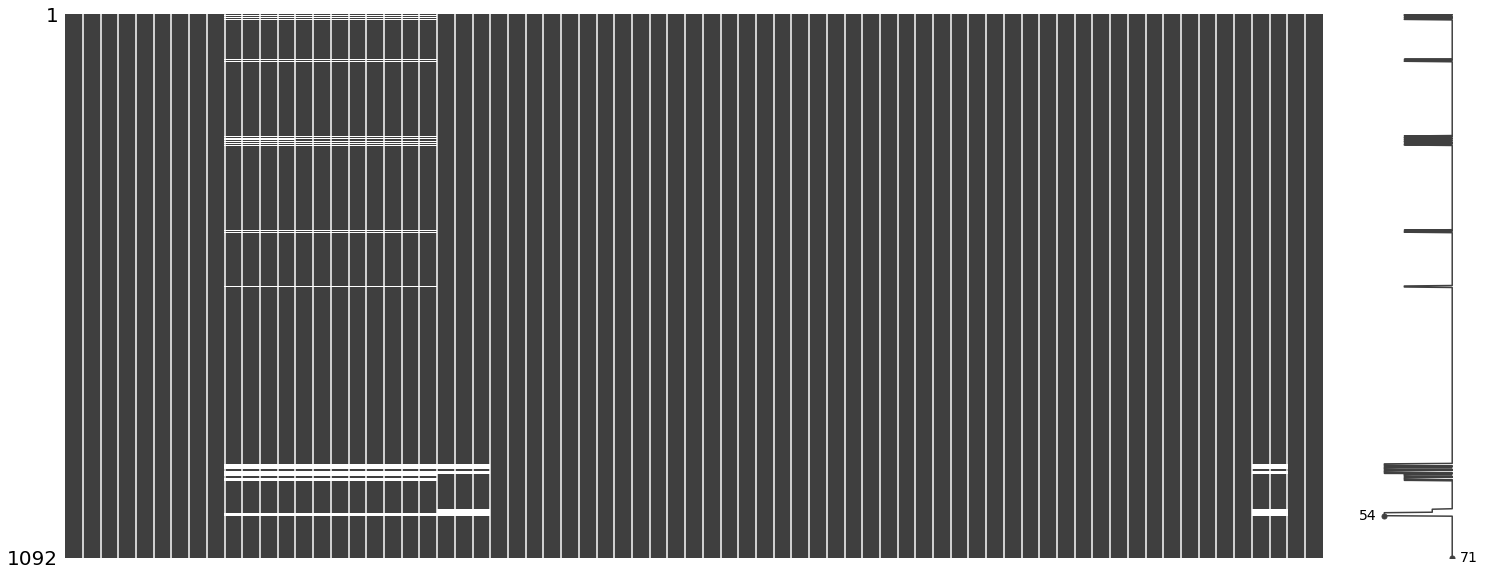

In [131]:
missingno.matrix(merged)

In [132]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

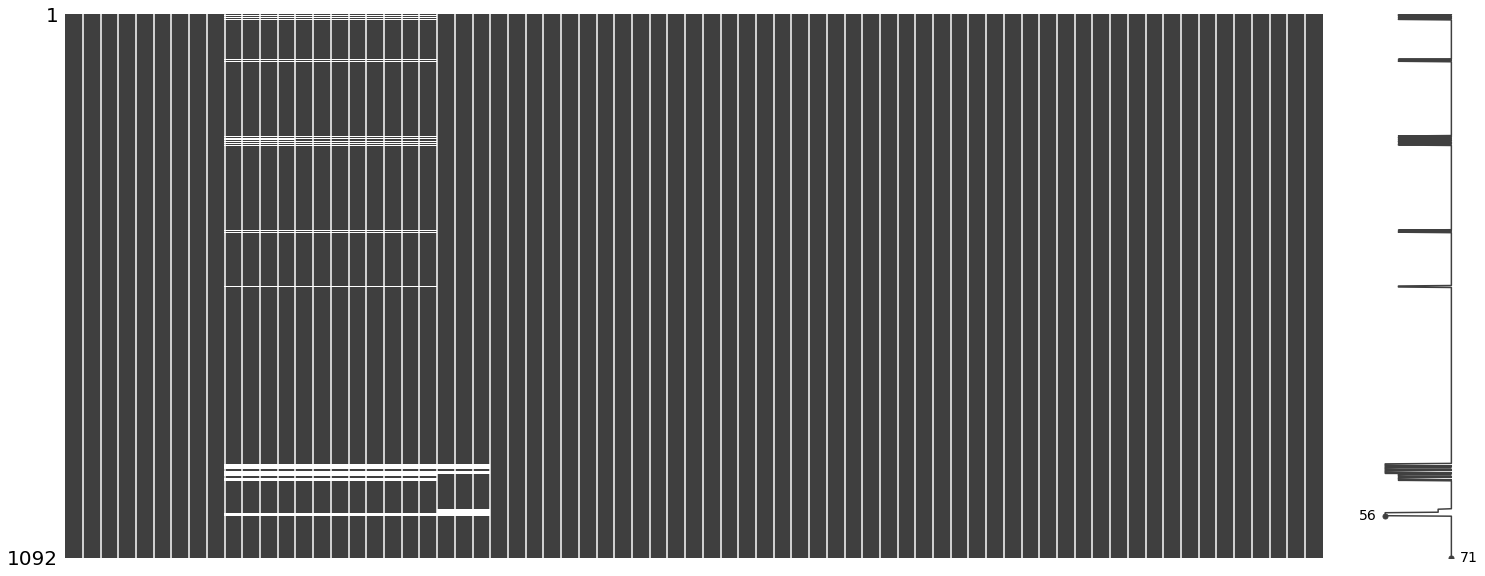

In [133]:
missingno.matrix(merged)

In [134]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [135]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['ημαθια', 'θεσσαλονικη', 'κιλκις', 'πελλα', 'πιερια', 'σερρες',
       'χαλκιδικη'], dtype=object)

In [136]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [137]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθια,2010,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
1,θεσσαλονικη,2010,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000
2,κιλκις,2010,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000
3,πελλα,2010,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000
4,πιερια,2010,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000
5,σερρες,2010,15.750000,19.833333,45.075758,882.274952,39.000000,-5.000000,44.000000,9.833333,25.666667,26.166667,4.500000,1423.000000,319.000000,11.000000,73.019474,505.000000,173.000000,270.000000,446.000000
6,χαλκιδικη,2010,16.083333,17.833333,45.726496,746.151743,37.000000,-2.000000,39.000000,11.333333,25.166667,25.333333,7.166667,1379.000000,385.000000,5.000000,93.001363,529.000000,168.000000,214.000000,430.000000
7,ημαθια,2011,13.916667,19.500000,48.750000,802.222292,35.000000,-5.000000,40.000000,13.666667,23.666667,23.666667,4.500000,874.000000,148.000000,14.000000,49.642554,296.000000,108.000000,108.000000,257.000000
8,θεσσαλονικη,2011,15.166667,20.833333,49.603175,884.033456,38.000000,-4.000000,42.000000,13.500000,26.000000,26.333333,5.166667,876.000000,143.000000,19.000000,56.510522,283.000000,113.000000,205.000000,234.000000
9,κιλκις,2011,15.208333,23.416667,45.915033,943.267612,40.000000,-11.000000,51.000000,12.833333,26.666667,27.166667,4.833333,798.000000,151.000000,5.000000,65.470755,265.000000,128.000000,195.000000,193.000000


In [138]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [139]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
7,2010-02,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.736428,1.371205,4.053816,10.208667,566.545455,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-4.002083,11.714000,285.842680,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
14,2010-03,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3,2010,0.306789,0.153101,-0.138970,-0.153101,0.299181,0.139387,-0.144685,-0.139387,0.042870,0.046756,0.048620,0.046756,15.908721,3.687326,9.798023,3.788843,1417.109091,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,0.445636,21.507455,117.454131,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
21,2010-04,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,4,2010,0.406513,0.144527,-0.232916,-0.144527,0.417933,0.143252,-0.242450,-0.143252,0.042646,0.045180,0.040471,0.045180,22.364242,7.348303,14.856273,2.476825,2164.836364,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,4.902364,27.275455,74.304749,0,14.583333,18.666667,49

In [140]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [141]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [142]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [143]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [144]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

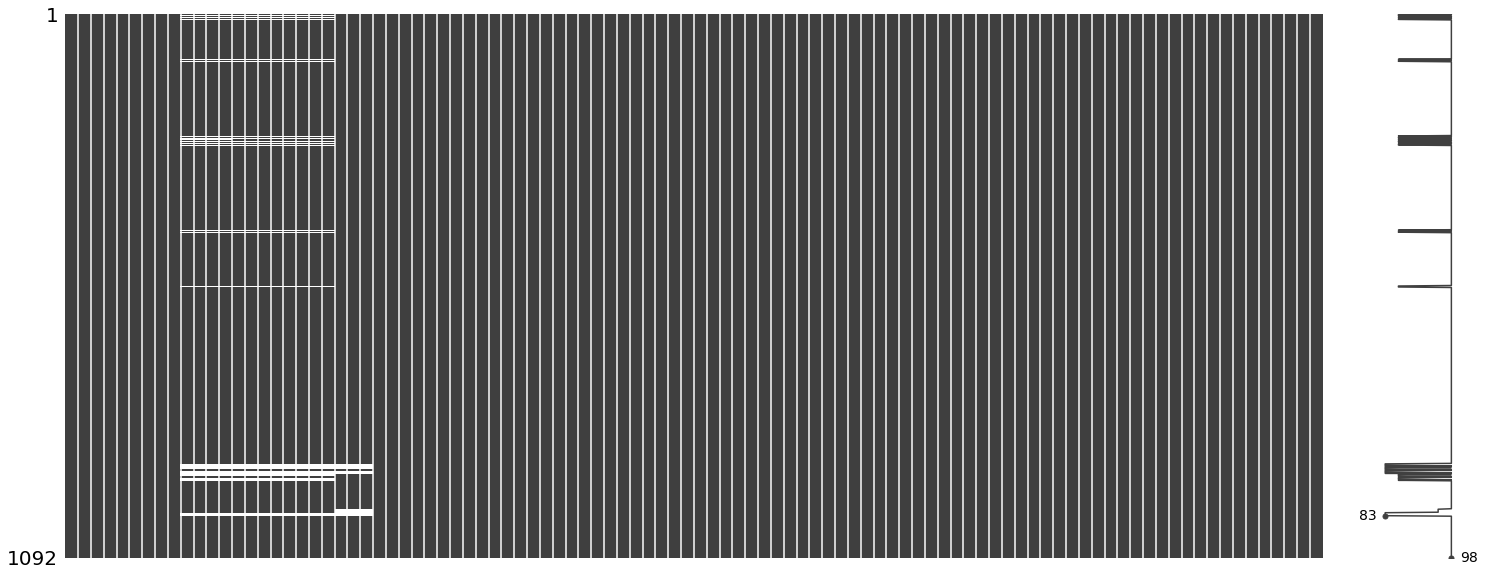

In [145]:
missingno.matrix(dataset)

In [146]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [147]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [148]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [149]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [150]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

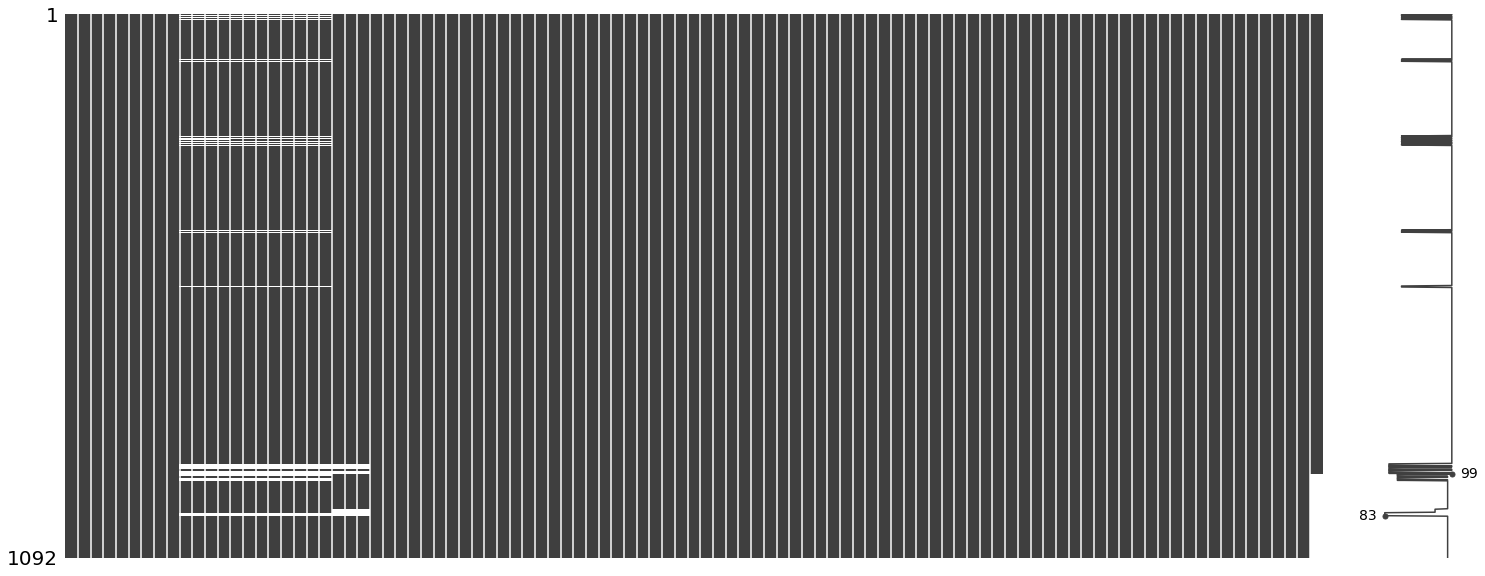

In [151]:
missingno.matrix(dataset)

In [152]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [153]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [154]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [155]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [156]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

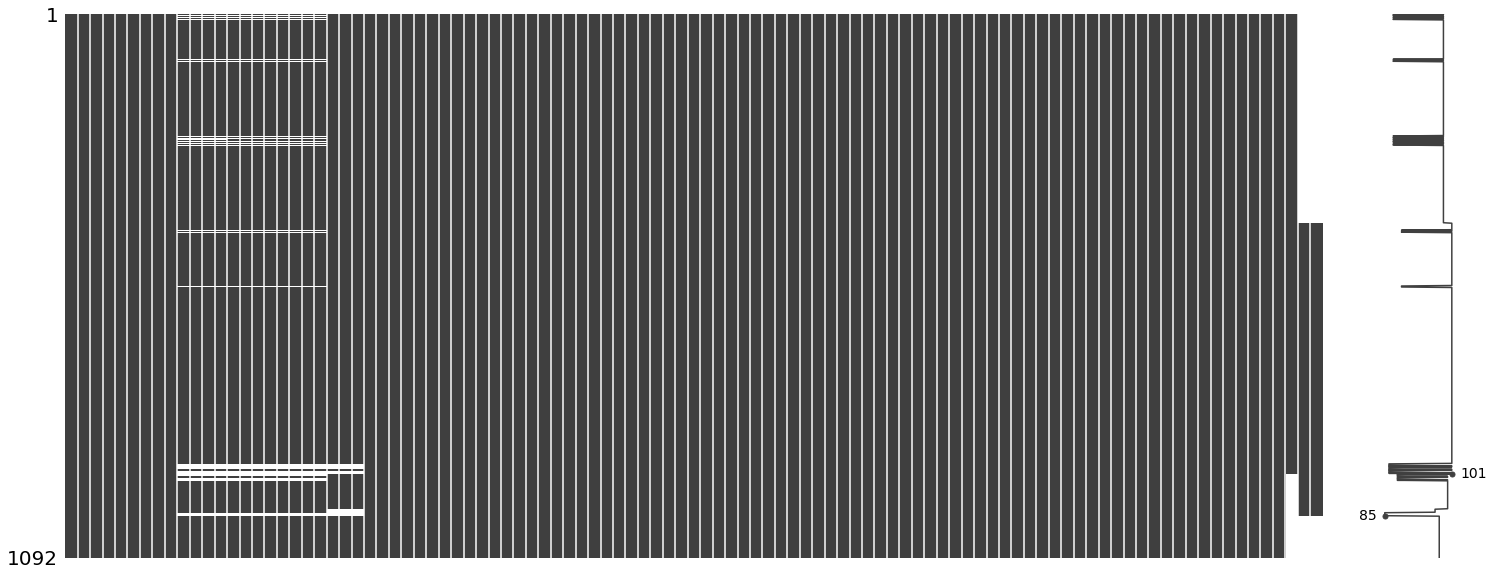

In [157]:
missingno.matrix(dataset)

In [158]:
missing = describe_dataframe(dataset)

In [159]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,0.000000
97,F_TOTAL,0.000000
98,MIO_EUR,15.384600
99,L_TOTAL,46.153800


In [160]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,4.816764,1.364895,740.125984,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,3.765541,1.715277,631.285714,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [161]:
dataset.reset_index(inplace=True, drop=True)

In [162]:
dataset['cases'].value_counts()

0     954
1      39
2      22
3      17
4      10
5       8
10      5
11      5
7       5
6       5
12      4
13      3
17      2
8       2
20      2
50      1
9       1
16      1
41      1
34      1
27      1
40      1
49      1
36      1
Name: cases, dtype: int64

In [163]:
dataset['cases'].sum()

863

In [164]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.000000,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,4.816764,1.364895,740.125984,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.000000,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,3.765541,1.715277,631.285714,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.000000,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [165]:
cols = dataset.columns

In [166]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [167]:
len(cols)

101

In [168]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc, index = False)
